Dataset Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


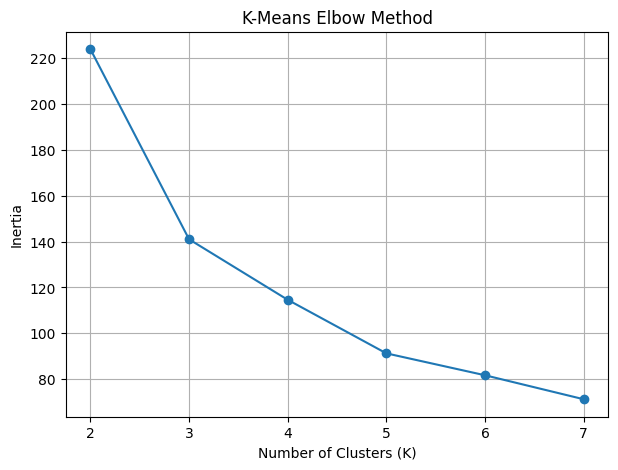

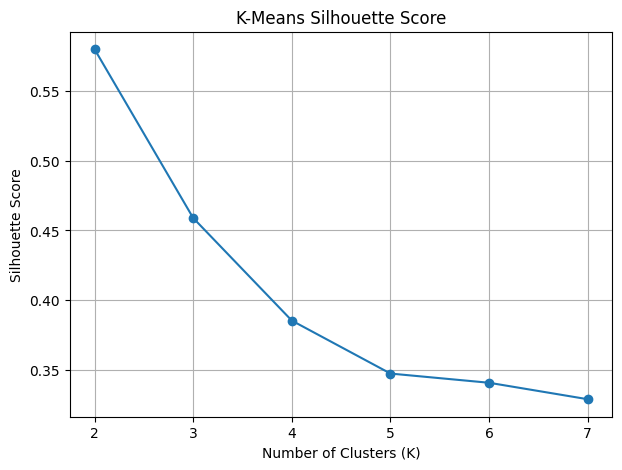

Best K: 2
Best Silhouette Score: 0.580184463257396

Cluster Counts:
KMeans_Cluster
0    100
1     50
Name: count, dtype: int64


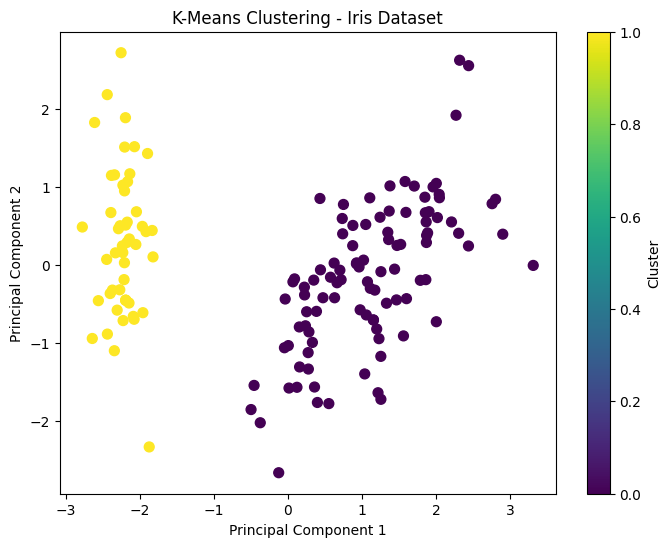


Cluster vs Species:
Species         Iris-setosa  Iris-versicolor  Iris-virginica
KMeans_Cluster                                              
0                         0               50              50
1                        50                0               0


In [1]:
# ============================================================
# K-MEANS CLUSTERING - IRIS DATASET
# Elbow Method + Silhouette Score
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("/content/Iris (2).csv")

print("Dataset Shape:", df.shape)

display(df.head())

# ------------------------------------------------------------
# 2. Select Features
# ------------------------------------------------------------

features = [
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]

X = df[features]

# ------------------------------------------------------------
# 3. Standardize Data
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ------------------------------------------------------------
# 4. Elbow Method
# ------------------------------------------------------------

inertia = []

K = range(2, 8)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot Elbow

plt.figure(figsize=(7,5))

plt.plot(
    K,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("K-Means Elbow Method")

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 5. Silhouette Score
# ------------------------------------------------------------

silhouette_scores = []

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

# Plot Silhouette Scores

plt.figure(figsize=(7,5))

plt.plot(
    K,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Score")

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 6. Find Best K
# ------------------------------------------------------------

best_k = list(K)[
    np.argmax(silhouette_scores)
]

print("Best K:", best_k)

print(
    "Best Silhouette Score:",
    max(silhouette_scores)
)

# ------------------------------------------------------------
# 7. Final K-Means
# ------------------------------------------------------------

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = clusters

print("\nCluster Counts:")

print(
    df["KMeans_Cluster"].value_counts().sort_index()
)

# ------------------------------------------------------------
# 8. PCA for Visualization
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Clustering - Iris Dataset")

plt.colorbar(label="Cluster")

plt.show()

# ------------------------------------------------------------
# 9. Compare Clusters with Species
# ------------------------------------------------------------

print("\nCluster vs Species:")

print(
    pd.crosstab(
        df["KMeans_Cluster"],
        df["Species"]
    )
)